<a href="https://colab.research.google.com/github/SVTINN/-_-_-_-_-_-_-_-_-/blob/main/%D0%A1%D0%B5%D1%80%D0%B5%D0%B1%D1%80%D1%8F%D0%BA%D0%BE%D0%B2%26%D0%A1%D0%B5%D0%B2%D1%80%D1%8E%D0%BA%26%D0%A2%D1%83%D1%80%D0%BA%D0%BE%D0%B2_%D0%9C%D0%B5%D1%82%D0%BE%D0%B4%D1%8B_%D0%B0%D0%BD%D0%B0%D0%BB%D0%B8%D0%B7%D0%B0_%D0%B4%D0%B0%D0%BD%D0%BD%D1%8B%D1%85_%D0%B2_%D0%B7%D0%B0%D0%B4%D0%B0%D1%87%D0%B0%D1%85_%D0%B8%D0%BD%D1%84%D0%BE%D1%80%D0%BC%D0%B0%D1%86%D0%B8%D0%BE%D0%BD%D0%BD%D0%BE%D0%B9_%D0%B1%D0%B5%D0%B7%D0%BE%D0%BF%D0%B0%D1%81%D0%BD%D0%BE%D1%81%D1%82%D0%B8(%D0%BF%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D0%BA%D0%B8)_%D0%A1%D0%B5%D1%80%D0%B5%D0%B1%D1%80%D1%8F%D0%BA%D0%BE%D0%B2%26%D0%A1%D0%B5%D0%B2%D1%80%D1%8E%D0%BA%26%D0%A2%D1%83%D1%80%D0%BA%D0%BE%D0%B2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ЛР№1

In [ ]:
'''
Анализ данных. Домашнее задание.

Севрюк
Серебряков
Турков
                                (Benjamin Sesko)
'''

In [ ]:
import os
import re
import sys
from pathlib import Path
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 25)
pd.set_option("display.width", 180)

try:
    import missingno as msno
    HAS_MSNO = True
except ImportError:
    HAS_MSNO = False


def save_fig(fig, name):
    fig.savefig(name, dpi=120, bbox_inches="tight")
    plt.show()
    plt.close(fig)

In [ ]:

# 1
csv_path = "data_example.csv"

raw = pd.read_csv(
    csv_path,
    sep=",",
    skiprows=[0],              # служебная строка метаданных
    header=[0, 1, 2, 3],       # Name / Units / Digital / Sample Rate
    encoding="utf-8",
    encoding_errors="ignore",
    low_memory=False,
)

print("Размер:", raw.shape)
print("Первые 5 заголовков:", list(raw.columns[:5]))

Размер: (26151, 96)
Первые 5 заголовков: [('Name', 'Units', 'Digital', 'Sample Rate'), ('10CT G PBP -1/+1:   --- EKC состояние', 'Unnamed: 1_level_1', '0', '2 мин'), ('10CT G PBP -1/+1:   u09 S5 Темп', 'degc', '0', '2 мин'), ('11CT G OVZ +5/+8:   u69 Sair Темп', 'degc', '0', '2 мин'), ('11CT G OVZ +5/+8:   u09 S5 Темп', 'degc', '0', '2 мин')]


In [ ]:
# 2
data = raw.copy()

# 2.1. чистим возможные пробелы/NA в служебной шапке
data.columns.names = ["level0", "level1", "level2", "level3"]

# 2.2. первая колонка — время (проверим, что это действительно она)
print("Первая колонка верхнего уровня:", data.columns[0][0])

# 2.3. приводим все ячейки к строкам, чтобы избежать смешанных типов
#     при дальнейшем dropna и парсинге чисел
data = data.applymap(lambda v: v.strip() if isinstance(v, str) else v)

# 2.4. явное приведение NA
data = data.replace({"": np.nan, " ": np.nan, "NA": np.nan, "NaN": np.nan})

print("Пропусков в исходной таблице:", data.isna().sum().sum())

Первая колонка верхнего уровня: Name


/tmp/ipykernel_412/3610000014.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  data = data.applymap(lambda v: v.strip() if isinstance(v, str) else v)


Пропусков в исходной таблице: 0


In [ ]:
# 3
data.columns = data.columns.droplevel([1, 2, 3])

def clean_header(col):
    text = re.sub(r"\s+", " ", str(col)).strip()
    text = text.replace("---", "").strip()
    parts = [p.strip() for p in text.split(":", 1)]
    return f"{parts[0]}: {parts[1]}" if len(parts) == 2 else text

new_cols = [clean_header(c) for c in data.columns]
new_cols[0] = "time"

# устраняем возможные дубликаты имён
seen = {}
uniq = []
for c in new_cols:
    if c in seen:
        seen[c] += 1
        uniq.append(f"{c} ({seen[c]})")
    else:
        seen[c] = 0
        uniq.append(c)

data.columns = uniq
print(data.columns[:10])

Index(['time', '10CT G PBP -1/+1: EKC состояние', '10CT G PBP -1/+1: u09 S5 Темп', '11CT G OVZ +5/+8: u69 Sair Темп', '11CT G OVZ +5/+8: u09 S5 Темп',
       '11CT G OVZ +5/+8: EKC состояние', '12CT G GSR +2/+4: u09 S5 Темп', '12CT G GSR +2/+4: u69 Sair Темп', '12CT G GSR +2/+4: EKC состояние',
       '13CT G PBP -1/+1: u69 Sair Темп'],
      dtype='object')


In [ ]:
# 4
# Вывод информации о датасете: его размер, название колонок, их типы данных

print("Размер:", data.shape)
print("Типы данных:")
print(data.dtypes)
print()
data.info()

Размер: (26151, 96)
Типы данных:
time                                object
10CT G PBP -1/+1: EKC состояние     object
10CT G PBP -1/+1: u09 S5 Темп       object
11CT G OVZ +5/+8: u69 Sair Темп     object
11CT G OVZ +5/+8: u09 S5 Темп       object
                                    ...   
111CT AG: Cond Requested Cap        object
111CT AG: Cond Running Cap          object
111CT AG: Cond Ctrl Pressure        object
111CT AG: Sc3 Датч нар воздуха     float64
111CT AG: Cond Reference            object
Length: 96, dtype: object

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26151 entries, 0 to 26150
Data columns (total 96 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   time                               26151 non-null  object 
 1   10CT G PBP -1/+1: EKC состояние    26151 non-null  object 
 2   10CT G PBP -1/+1: u09 S5 Темп      26151 non-null  object 
 3   11CT G OVZ +5/+8: u69 Sair Темп  

In [ ]:
# 5
data["time"] = data["time"].astype(str).str.strip()
data["time"] = pd.to_datetime(data["time"], format="%H:%M:%S  %d/%m/%Y", errors="coerce")
data = data.dropna(subset=["time"])
data = data.set_index("time").sort_index()

print("Диапазон:", data.index.min(), "..", data.index.max())
print("Монотонно возрастает:", data.index.is_monotonic_increasing)

# параллельно приведём все прочие колонки к numeric
state_cols = [c for c in data.columns if "EKC состояние" in c]
for c in [c for c in data.columns if c not in state_cols]:
    data[c] = pd.to_numeric(data[c], errors="coerce")

Диапазон: 2021-03-01 00:00:00 .. 2021-04-06 07:40:00
Монотонно возрастает: True


Gazoanalyzator: Gas Level Ppm      10
Gazoanalyzator: Gas Level %        10
20CT G GSR +2/+4: u69 Sair Темп     9
20CT G GSR +2/+4: u09 S5 Темп       9
55CT K GSR +2/+4: u09 S5 Темп       8
                                   ..
111CT AG: Comp A Capacity           6
111CT AG: Cond Requested Cap        6
111CT AG: Cond Running Cap          6
111CT AG: Cond Ctrl Pressure        6
111CT AG: Cond Reference            6
Length: 67, dtype: int64


/usr/local/lib/python3.13/dist-packages/missingno/missingno.py:61: UserWarning: Plotting a sparkline on an existing axis is not currently supported. To remove this warning, set sparkline=False.
  warnings.warn(


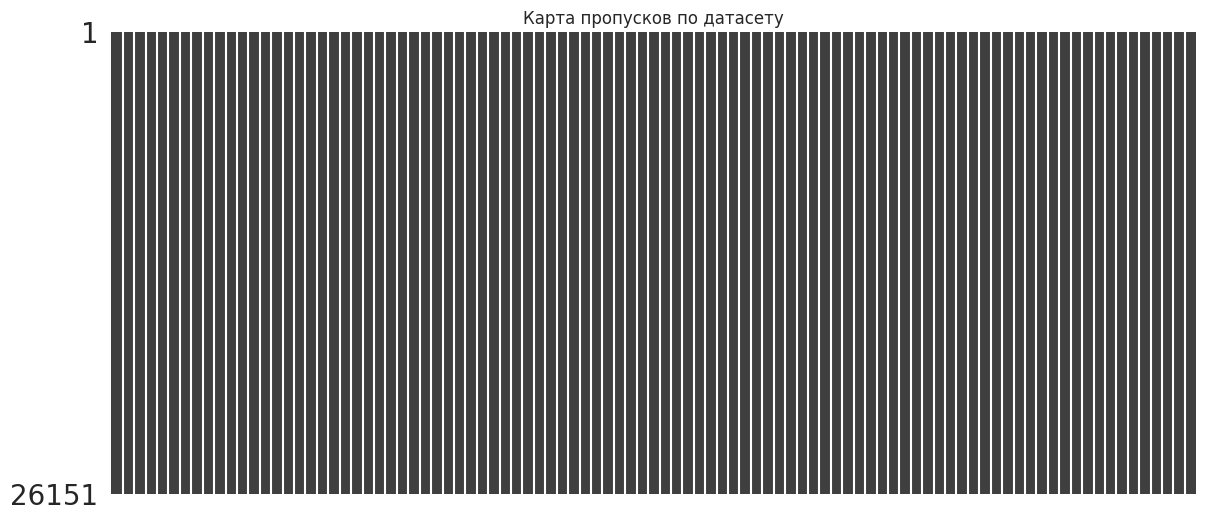

In [ ]:
# 6
gaps = data.isna().sum()
gaps = gaps[gaps > 0].sort_values(ascending=False)
print(gaps)

fig, ax = plt.subplots(figsize=(14, 6))
if HAS_MSNO:
    msno.matrix(data, ax=ax)
else:
    sns.heatmap(data.isna(), cbar=False, yticklabels=False, cmap="viridis", ax=ax)
ax.set_title("Карта пропусков по датасету")
save_fig(fig, "06_missing_values.png")

In [ ]:
# 7
mem_before = data.memory_usage(deep=True).sum() / 1024**2

data_opt = data.copy()
value_cols = [c for c in data_opt.columns if c not in state_cols]

# целочисленные -> Int64 (nullable, хранит NaN)
for c in value_cols:
    s = data_opt[c].dropna()
    if len(s) and np.allclose(s, s.round()):
        data_opt[c] = data_opt[c].astype("Int64")

# категориальные: EKC-состояния и низкокардинальные (<=10 значений)
for c in state_cols:
    data_opt[c] = data_opt[c].astype("category")
for c in value_cols:
    if data_opt[c].nunique(dropna=True) <= 10:
        data_opt[c] = data_opt[c].astype("category")

mem_after = data_opt.memory_usage(deep=True).sum() / 1024**2
print(f"До:  {mem_before:.2f} МБ")
print(f"После: {mem_after:.2f} МБ")
print(f"Экономия: {(1 - mem_after / mem_before) * 100:.1f}%")

До:  47.88 МБ
После: 13.71 МБ
Экономия: 71.4%


['21CT G GSR +2/+4: u69 Sair Темп', '22CT G GSR +2/+4: u69 Sair Темп', '23CT V MSO -1/+1: u69 Sair Темп', '24CT V GSR +2/+4: u69 Sair Темп', '25CT V GSR +2/+4: u69 Sair Темп', '26CT G MLK +2/+4: u69 Sair Темп', '27CT G MLK +2/+4: u69 Sair Темп', '28CT G MLK +2/+4: u69 Sair Темп', '29CT G MLK +2/+4: u69 Sair Темп', '30CT G GSR +2/+4: u69 Sair Темп']
       21CT G GSR +2/+4: u69 Sair Темп  22CT G GSR +2/+4: u69 Sair Темп  23CT V MSO -1/+1: u69 Sair Темп  24CT V GSR +2/+4: u69 Sair Темп  25CT V GSR +2/+4: u69 Sair Темп  \
count                     26143.000000                     26143.000000                     26143.000000                     26143.000000                     26143.000000   
mean                          4.327670                         4.920989                        -0.561605                        -0.511476                         2.771393   
std                           3.081583                         3.186743                         2.864368                       

/tmp/ipykernel_412/556526999.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


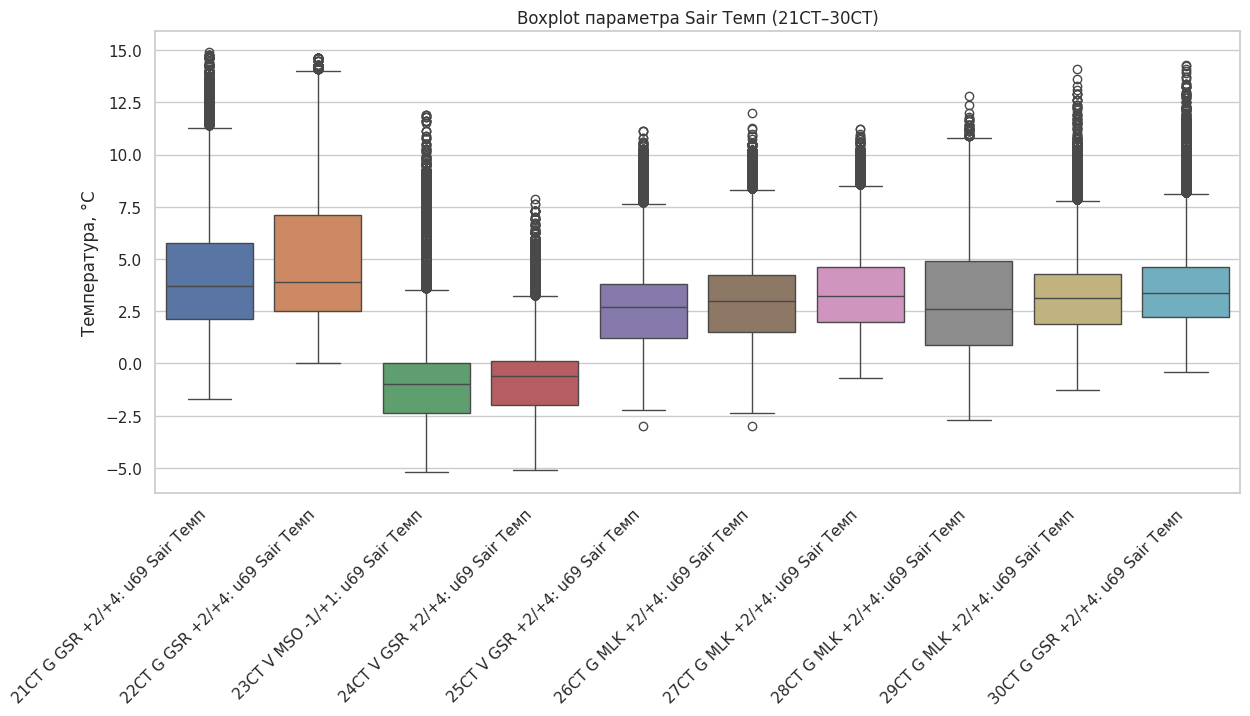

In [ ]:
# 8
col_Sair = [
    c for c in data.columns
    if "Sair" in c and any(c.startswith(f"{n}CT") for n in range(21, 31))
]
print(col_Sair)
print(data[col_Sair].describe())

fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(data=data[col_Sair], ax=ax)
ax.set_title("Boxplot параметра Sair Темп (21CT–30CT)")
ax.set_ylabel("Температура, °C")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
save_fig(fig, "08_boxplot_sair.png")

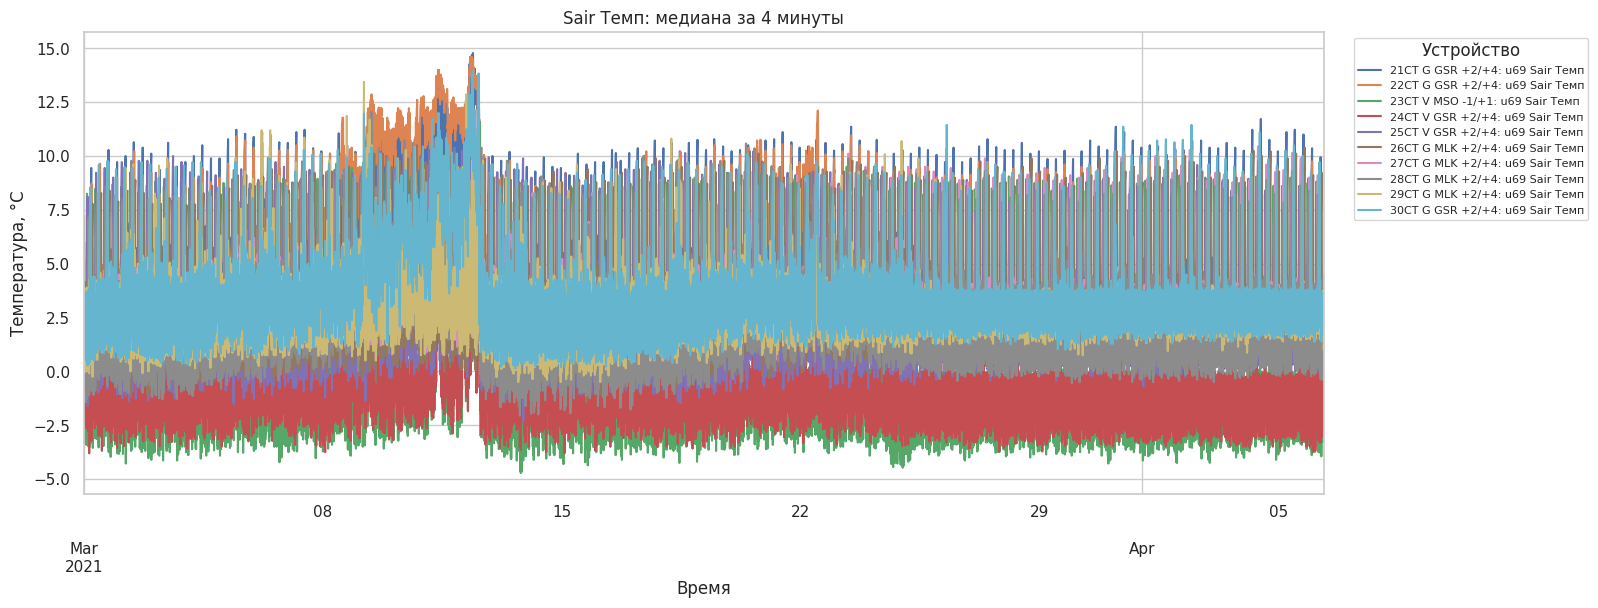

In [ ]:
# 9
resampled = data[col_Sair].resample("4min").median()

fig, ax = plt.subplots(figsize=(16, 6))
resampled.plot(ax=ax)
ax.set_title("Sair Темп: медиана за 4 минуты")
ax.set_xlabel("Время")
ax.set_ylabel("Температура, °C")
ax.legend(title="Устройство", loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=8)
save_fig(fig, "09_resampled_sair.png")

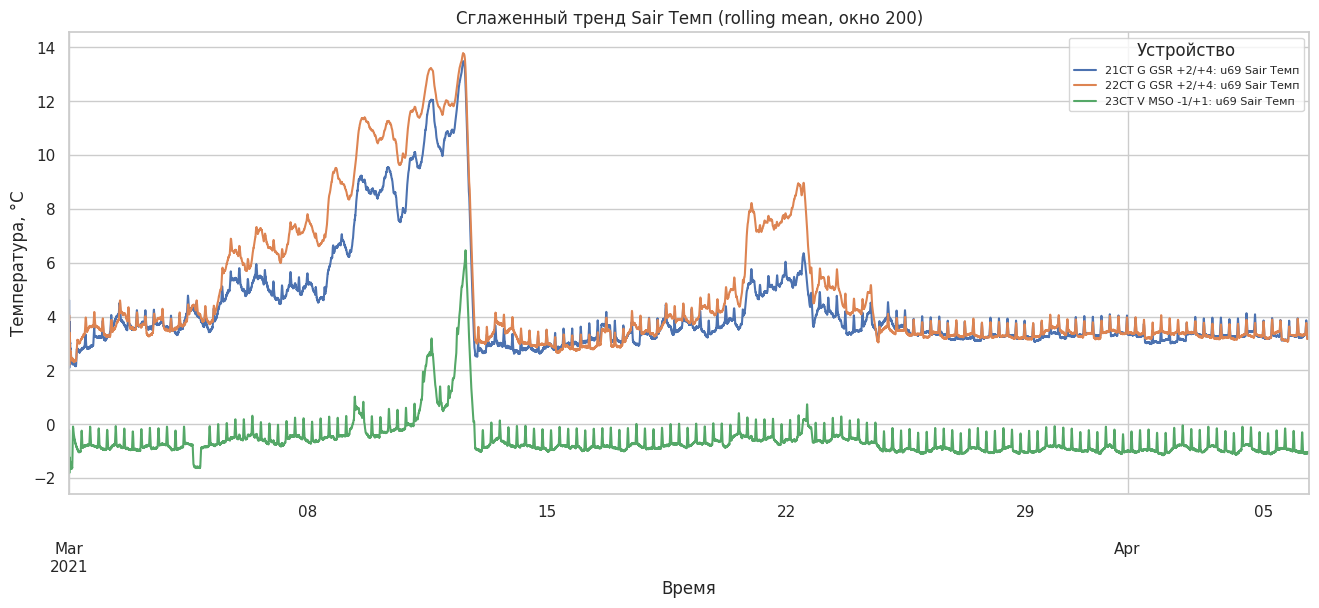

In [ ]:
# 10
trend_cols = col_Sair[:3]
smoothed = data[trend_cols].rolling(window=200, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(16, 6))
smoothed.plot(ax=ax)
ax.set_title("Сглаженный тренд Sair Темп (rolling mean, окно 200)")
ax.set_xlabel("Время")
ax.set_ylabel("Температура, °C")
ax.legend(title="Устройство", fontsize=8)
save_fig(fig, "10_rolling_trend.png")

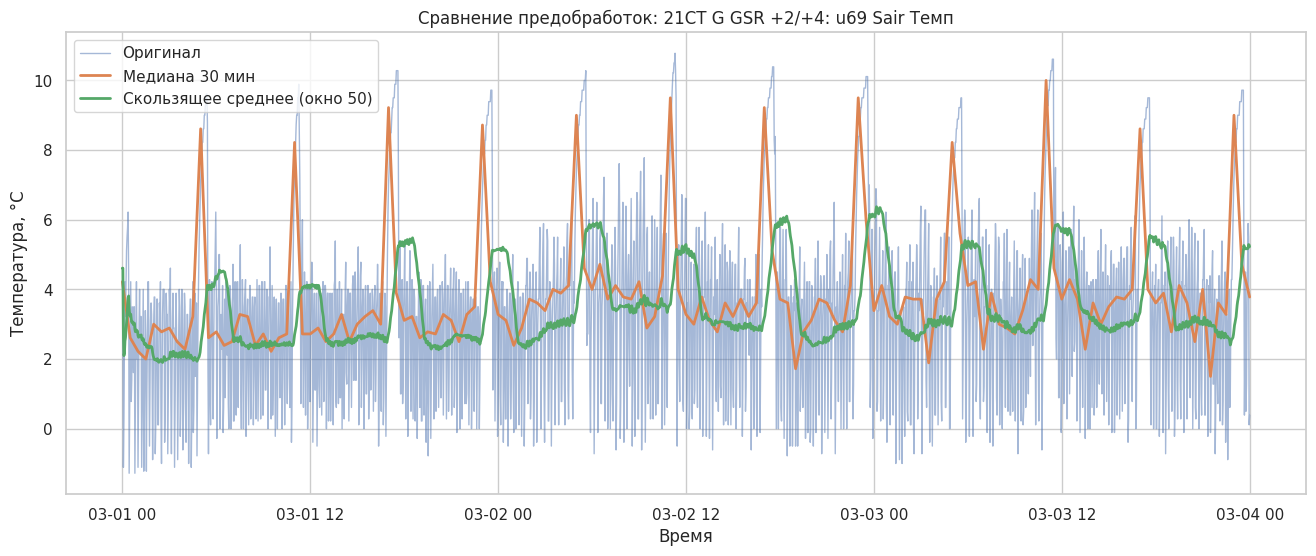

In [ ]:
# 11
target_col = col_Sair[0]
left = data.index.min()
right = left + pd.Timedelta(days=3)

original = data[target_col].loc[left:right]
re_sampled = data[target_col].resample("30min").median().loc[left:right]
smoothed_w = data[target_col].rolling(window=50, min_periods=1).mean().loc[left:right]

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(original.index, original.values, label="Оригинал", alpha=0.5, linewidth=1)
ax.plot(re_sampled.index, re_sampled.values, label="Медиана 30 мин", linewidth=2)
ax.plot(smoothed_w.index, smoothed_w.values, label="Скользящее среднее (окно 50)", linewidth=2)
ax.set_title(f"Сравнение предобработок: {target_col}")
ax.set_xlabel("Время")
ax.set_ylabel("Температура, °C")
ax.legend()
save_fig(fig, "11_comparison.png")

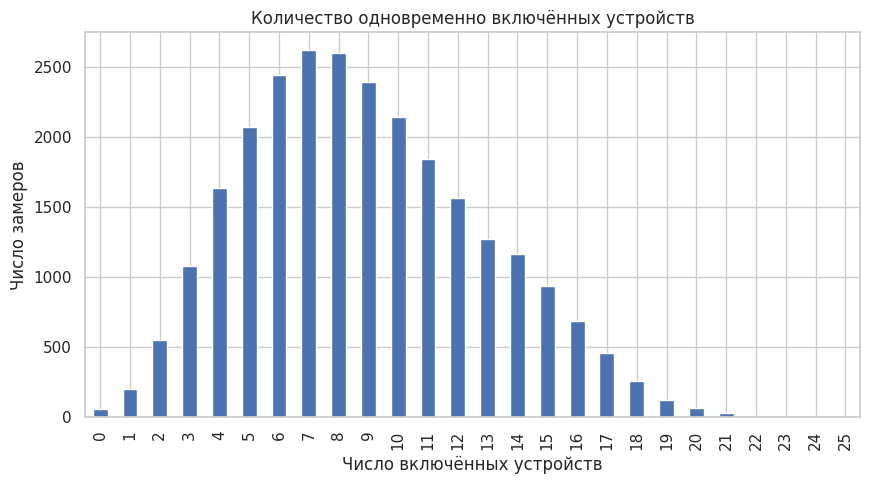

In [ ]:
# 12
# «включено» == EKC состояние равно 0
state_map = data[state_cols].apply(
    lambda s: (s.astype(str).str.strip() == "0").astype(int)
)
counts_on = state_map.sum(axis=1)

fig, ax = plt.subplots(figsize=(10, 5))
counts_on.value_counts().sort_index().plot.bar(ax=ax)
ax.set_title("Количество одновременно включённых устройств")
ax.set_xlabel("Число включённых устройств")
ax.set_ylabel("Число замеров")
save_fig(fig, "12_devices_on_hist.png")

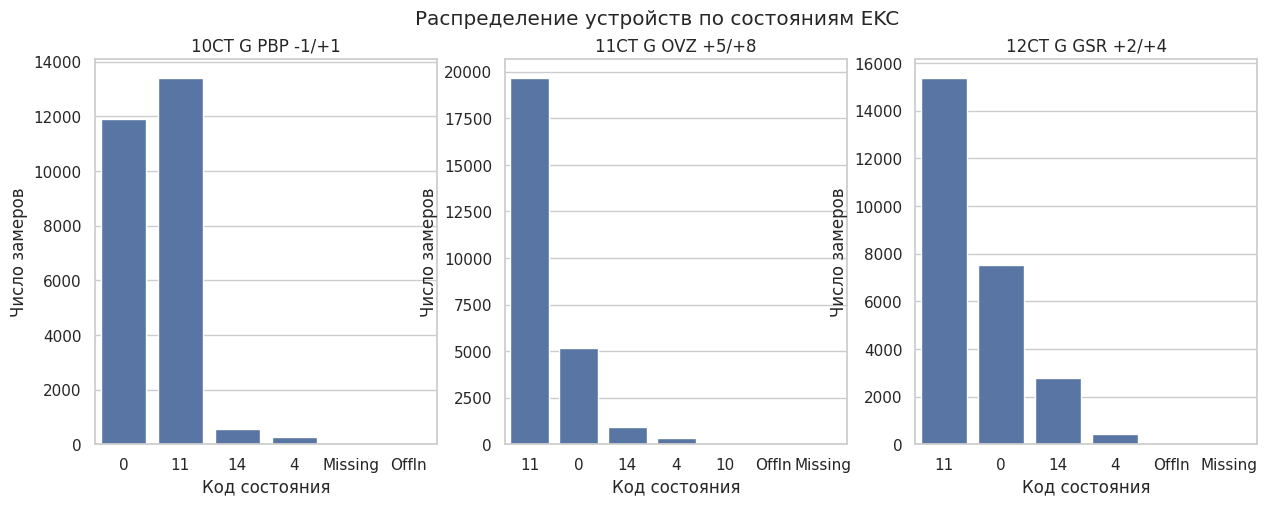

In [ ]:
# 13
sample_state_cols = state_cols[:3]
fig, axes = plt.subplots(1, len(sample_state_cols), figsize=(5 * len(sample_state_cols), 5))
if len(sample_state_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, sample_state_cols):
    sns.countplot(x=data[col].dropna(), ax=ax)
    ax.set_title(col.replace(": EKC состояние", ""))
    ax.set_xlabel("Код состояния")
    ax.set_ylabel("Число замеров")

fig.suptitle("Распределение устройств по состояниям EKC")
save_fig(fig, "13_states_hist.png")

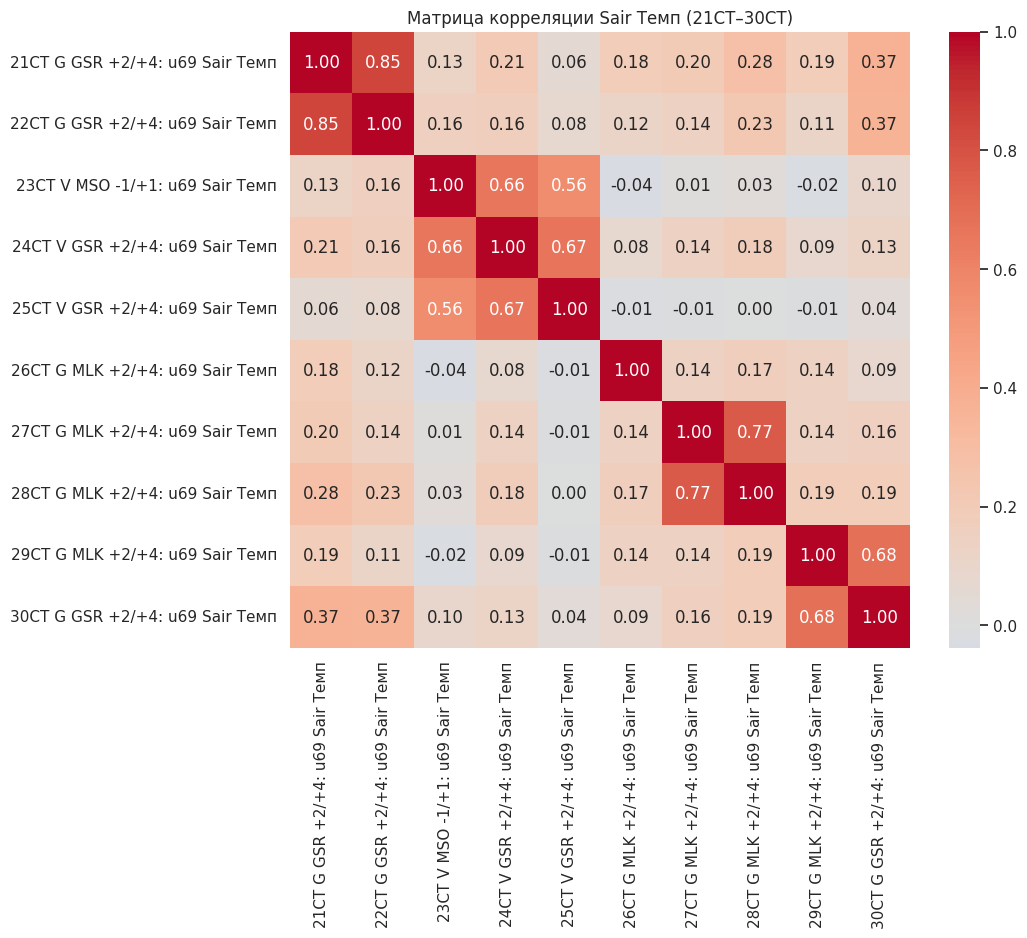

In [ ]:
# 14
corr = data[col_Sair].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Матрица корреляции Sair Темп (21CT–30CT)")
save_fig(fig, "14_correlation.png")

Устройство: 10CT G PBP -1/+1
Температура: 10CT G PBP -1/+1: u09 S5 Темп
                                   count      mean       std    min      25%   50%   75%    max
10CT G PBP -1/+1: EKC состояние                                                                
0                                11904.0 -5.461515  8.693702 -18.50 -14.2200 -6.61  3.89  10.72
11                               13413.0 -3.697268  7.155279 -18.28  -9.7200 -1.11  1.89   8.89
14                                 568.0  5.197588  4.218519 -12.50   5.1925  7.11  7.50   8.28
4                                  260.0  8.730808  0.933255   7.28   7.9725  8.39  9.50  11.61
Missing                              0.0       NaN       NaN    NaN      NaN   NaN   NaN    NaN
Offln                                0.0       NaN       NaN    NaN      NaN   NaN   NaN    NaN


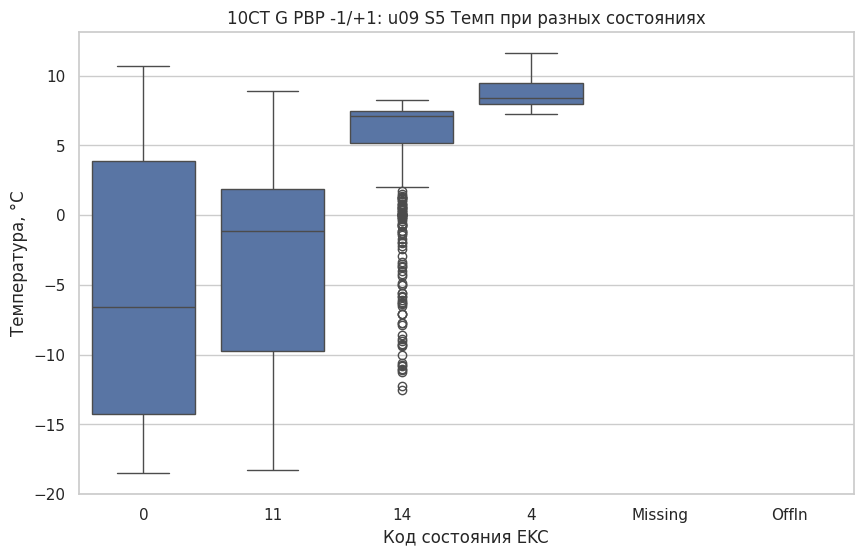


Средняя температура при state=0: -5.46 °C
Гипотеза подтверждается: в рабочем режиме температура ниже.


In [ ]:
# 15
# Гипотеза: температура u09 S5 внутри устройства зависит от состояния EKC.
device = state_cols[0].split(":", 1)[0]
temp_col = f"{device}: u09 S5 Темп"
state_col = state_cols[0]

print("Устройство:", device)
print("Температура:", temp_col)

grouped = data.groupby(state_col, observed=True)[temp_col].describe()
print(grouped)

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(x=data[state_col].astype(str), y=data[temp_col], ax=ax)
ax.set_title(f"{temp_col} при разных состояниях")
ax.set_xlabel("Код состояния EKC")
ax.set_ylabel("Температура, °C")
save_fig(fig, "15_hypothesis.png")

on_key = next((k for k in grouped.index if str(k).strip() == "0"), None)
if on_key is not None:
    on_mean = grouped.loc[on_key, "mean"]
    others = grouped.drop(index=on_key, errors="ignore")["mean"].dropna()
    print(f"\nСредняя температура при state=0: {on_mean:.2f} °C")
    if len(others) and (others > on_mean).all():
        print("Гипотеза подтверждается: в рабочем режиме температура ниже.")
    else:
        print("Гипотеза требует уточнения: разница не для всех состояний однозначна.")

In [ ]:
'''
Анализ данных. Домашнее задание.

Севрюк
Серебряков
Турков
                                (Benjamin Sesko)
'''